# Class-imbalance strategy comparison — full nested CV (SVM & Random Forest)

**Not run by Claude — written but not executed, per explicit request.** Every
individual building block below (`SentinelMedianImputer`,
`make_race_time_series_splits`, the nested outer/inner CV loop structure) is
copied unmodified from the already-tested `svm_nested_cv_optimization.ipynb`
and `rf_nested_cv_aligned.ipynb`. What is **new and untested** is only the
outer loop that repeats this same structure across 2 models x 3 imbalance
strategies = 6 combinations. Decision Tree is not included (dropped per
instruction).

**Cost warning, explicit**: this is 6 combinations x 5 outer folds x
`n_iter` inner-search iterations each = a lot of fits. `n_iter` is set to 30
per combination below (not 80, as in the single-model notebooks) specifically
to keep total runtime manageable — 6 x 5 x 30 x 3(inner folds) = 2700 fits
vs. the ~1200 a single aligned SVM or RF notebook runs. If 30 is still too
slow on your machine, lower it further; a smaller `n_iter` here is a
reasonable trade-off for a multi-strategy screening pass, not a compromise
you'd want for the final single-model report numbers.

In [2]:
import numpy as np
import pandas as pd
import os
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from scipy.stats import loguniform
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
import time

# --- EDIT THIS: point to your local prediction.csv ---
DATA_PATH = "./prediction.csv"
OUTPUT_DIR = "."

RANDOM_STATE = 42
SENTINEL = -1
N_ITER_PER_COMBO = 30   # lower than the single-model notebooks (80) -- see cost warning above

## 1. Load data and define the 12 aligned features (same as the final SVM/RF comparison)

In [3]:
df = pd.read_csv(DATA_PATH)

feature_cols = [
    "grid", "qualifying_position", "driver_std_position_prev", "constructor_std_position_prev",
    "driver_avg_position_last3", "driver_podium_rate_last10", "driver_points_avg_last3",
    "constructor_avg_position_last3", "driver_avg_position_at_circuit",
    "teammate_h2h_avg_position_delta", "driver_dnf_rate_historical", "points_gap_to_leader",
]

train_mask = (df.year >= 2021) & (df.year <= 2024)
df_train_dev = df.loc[train_mask].sort_values(["date", "raceId"]).reset_index(drop=True)
print(f"Train/dev rows: {len(df_train_dev)}, races: {df_train_dev['raceId'].nunique()}")

Train/dev rows: 1799, races: 90


## 2. Race-level TimeSeriesSplit helper (identical to the SVM/RF aligned notebooks)

In [4]:
def make_race_time_series_splits(data, n_splits):
    ordered_races = (data[["raceId", "date"]]
                     .drop_duplicates()
                     .sort_values(["date", "raceId"])
                     .reset_index(drop=True))
    race_ids = ordered_races["raceId"].to_numpy()
    race_cv = TimeSeriesSplit(n_splits=n_splits)
    for train_race_idx, test_race_idx in race_cv.split(race_ids):
        train_races = set(race_ids[train_race_idx])
        test_races = set(race_ids[test_race_idx])
        train_row_idx = data.index[data["raceId"].isin(train_races)].to_numpy()
        test_row_idx = data.index[data["raceId"].isin(test_races)].to_numpy()
        yield train_row_idx, test_row_idx

outer_splits = list(make_race_time_series_splits(df_train_dev, n_splits=5))
print(f"Outer folds: {len(outer_splits)}")

Outer folds: 5


## 3. `SentinelMedianImputer` (identical to the aligned SVM/RF notebooks)

In [5]:
class SentinelMedianImputer(BaseEstimator, TransformerMixin):
    """Replace sentinel values with training medians and append missing indicators."""

    def __init__(self, feature_names=None, sentinel_columns=None, sentinel_value=-1):
        self.feature_names = feature_names
        self.sentinel_columns = sentinel_columns
        self.sentinel_value = sentinel_value

    def fit(self, X, y=None):
        X_arr = np.asarray(X, dtype=float)
        self.feature_names_ = list(self.feature_names) if self.feature_names is not None else [
            f"feature_{idx}" for idx in range(X_arr.shape[1])
        ]
        self.sentinel_columns_ = list(self.sentinel_columns or [])
        self.sentinel_indices_ = [self.feature_names_.index(col) for col in self.sentinel_columns_]
        self.medians_ = {}
        for col, idx in zip(self.sentinel_columns_, self.sentinel_indices_):
            values = X_arr[:, idx]
            valid_values = values[values != self.sentinel_value]
            self.medians_[idx] = float(np.median(valid_values)) if len(valid_values) else 0.0
        return self

    def transform(self, X):
        X_arr = np.asarray(X, dtype=float).copy()
        indicators = []
        for idx in self.sentinel_indices_:
            missing_mask = X_arr[:, idx] == self.sentinel_value
            indicators.append(missing_mask.astype(float))
            X_arr[missing_mask, idx] = self.medians_[idx]
        if indicators:
            return np.hstack([X_arr, np.column_stack(indicators)])
        return X_arr

## 4. Model + strategy + search-space definitions

For each model, `param_distribution` mirrors the real, working config already
used in `svm_nested_cv_optimization.ipynb` / `rf_nested_cv_aligned.ipynb` ,
not re-derived from scratch. `class_weight` is fixed to `"balanced"` for the
no-oversampling strategy, and to `None` for SMOTE/RandomOverSampler (the
resampler already balances the classes, so re-weighting on top of that would
double-correct).

In [6]:
def make_svm_pipeline(sentinel_cols, class_weight):
    return Pipeline([
        ("sentinel", SentinelMedianImputer(feature_names=feature_cols,
                                            sentinel_columns=sentinel_cols, sentinel_value=SENTINEL)),
        ("scaler", RobustScaler()),
        ("svc", SVC(class_weight=class_weight, random_state=RANDOM_STATE, max_iter=10000)),
    ])

def make_rf_pipeline(sentinel_cols, class_weight):
    return Pipeline([
        ("sentinel", SentinelMedianImputer(feature_names=feature_cols,
                                            sentinel_columns=sentinel_cols, sentinel_value=SENTINEL)),
        ("rf", RandomForestClassifier(class_weight=class_weight, random_state=RANDOM_STATE, n_jobs=-1)),
    ])

svm_param_dist = {
    "svc__C": loguniform(1, 300),
    "svc__gamma": loguniform(0.0005, 0.05),
    "svc__kernel": ["rbf", "linear"],
}

rf_param_dist = {
    "rf__n_estimators": [200, 300, 500, 800],
    "rf__max_depth": [None, 4, 6, 8, 10, 12],
    "rf__min_samples_split": [2, 5, 10, 20],
    "rf__min_samples_leaf": [1, 2, 4, 8],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
    "rf__criterion": ["gini", "entropy"],
    "rf__max_samples": [0.6, 0.75, 0.9, None],
}

model_configs = {
    "SVM": (make_svm_pipeline, svm_param_dist),
    "Random Forest": (make_rf_pipeline, rf_param_dist),
}

# strategy name -> (imblearn sampler or None, class_weight)
strategy_configs = {
    "No oversampling (class_weight=balanced)": (None, "balanced"),
    "SMOTE": (SMOTE(random_state=RANDOM_STATE, k_neighbors=3), None),
    "Random oversampling": (RandomOverSampler(random_state=RANDOM_STATE), None),
    "Random undersampling": (RandomUnderSampler(random_state=RANDOM_STATE), None),
}

## 5. Full nested CV: outer 5 folds x inner 3 folds, for every (model, strategy)

Same nested structure as the single-model notebooks: for each outer fold, an
inner `RandomizedSearchCV` (race-level `TimeSeriesSplit`, 3 folds) selects
hyperparameters using only that outer fold's training data, then the best
inner model is evaluated once on that outer fold's held-out test data.


In [2]:
results = []

for model_name, (make_pipeline_fn, param_dist) in model_configs.items():
    for strategy_name, (sampler, class_weight) in strategy_configs.items():
        print(f"=== {model_name} / {strategy_name} ===")
        for fold_idx, (train_idx, test_idx) in enumerate(outer_splits, start=1):
            train_df = df_train_dev.iloc[train_idx].reset_index(drop=True)
            test_df = df_train_dev.iloc[test_idx]

            X_train = train_df[feature_cols].to_numpy()
            y_train = train_df["target"].to_numpy()
            X_test = test_df[feature_cols].to_numpy()
            y_test = test_df["target"].to_numpy()

            base_pipeline = make_pipeline_fn(feature_cols, class_weight)
            if sampler is not None:
                steps = list(base_pipeline.steps)
                steps.insert(1, ("resample", sampler))
                pipeline = ImbPipeline(steps)
            else:
                pipeline = ImbPipeline(base_pipeline.steps)

            inner_splits = list(make_race_time_series_splits(train_df, n_splits=3))

            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_dist,
                n_iter=N_ITER_PER_COMBO,
                scoring="f1_macro",
                cv=inner_splits,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                refit=True,
            )
            start_time = time.time()
            search.fit(X_train, y_train)
            elapsed_time = time.time() - start_time
            y_pred = search.predict(X_test)
            best_model = search.best_estimator_

            #stored it in search.refit_time_

            refit_only_time = search.refit_time_
            search_only_time = elapsed_time - refit_only_time

            n_iter_actual = None
            if "svc" in best_model.named_steps:
                n_iter_val = best_model.named_steps["svc"].n_iter_
                n_iter_actual = int(n_iter_val[0]) if hasattr(n_iter_val, "__len__") else int(n_iter_val)
            results.append({
                "model": model_name,
                "strategy": strategy_name,
                "fold": fold_idx,
                "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
                "val_macro_f1": search.best_score_,
                "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
                "f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
                "training_time_sec": elapsed_time,
                "refit_only_time_sec": refit_only_time,
                "search_only_time_sec": search_only_time,
                "svm_n_iter_actual": n_iter_actual,
                "best_params": search.best_params_,
            })
            print(f"  fold {fold_idx}/5 done | macro_f1={results[-1]['f1']:.4f}")

results_df = pd.DataFrame(results)
results_df

NameError: name 'model_configs' is not defined

## 6. Save raw per-fold results (append future runs to the same tracking file)

In [8]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_csv = os.path.join(OUTPUT_DIR, "imbalance_strategy_tracking_nestedcv.csv")
results_df.drop(columns=["best_params"]).to_csv(out_csv, index=False)
print(f"Saved to {out_csv}")

import json
params_path = os.path.join(OUTPUT_DIR, "imbalance_strategy_best_params.json")
with open(params_path, "w") as f:
    json.dump(
        [{"model": r["model"], "strategy": r["strategy"], "fold": r["fold"], "best_params": r["best_params"]}
         for r in results],
        f, indent=2, default=str)
print(f"Saved best params per fold to {params_path}")

Saved to .\imbalance_strategy_tracking_nestedcv.csv
Saved best params per fold to .\imbalance_strategy_best_params.json


## 7. Boxplots — precision / recall / F1 by (model, strategy)

Saved figure to .\imbalance_strategy_boxplots_nestedcv.png


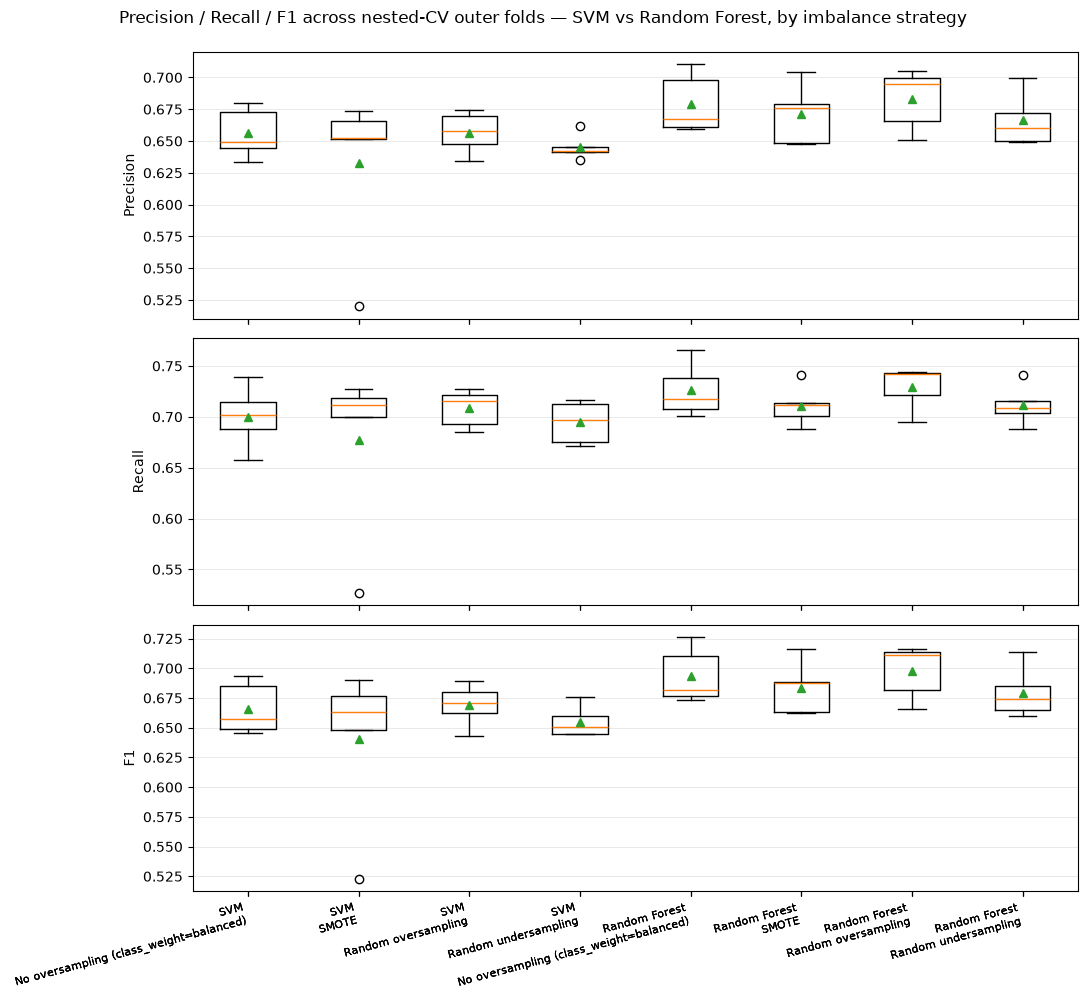

In [9]:
results_df["combo"] = results_df["model"] + "\n" + results_df["strategy"]
combo_order = [f"{m}\n{s}" for m in model_configs for s in strategy_configs]

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for ax, metric in zip(axes, ["precision", "recall", "f1"]):
    data = [results_df.loc[results_df["combo"] == c, metric].values for c in combo_order]
    ax.boxplot(data, tick_labels=combo_order, showmeans=True)
    ax.set_ylabel(metric.capitalize())
    ax.grid(axis="y", linestyle="-", linewidth=0.4, alpha=0.5)

plt.xticks(rotation=15, ha="right", fontsize=8)
plt.suptitle("Precision / Recall / F1 across nested-CV outer folds \u2014 SVM vs Random Forest, by imbalance strategy", y=0.995)
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "imbalance_strategy_boxplots_nestedcv.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

## 8. Summary table (mean ± std per combination)

In [10]:
summary = (results_df.groupby(["model", "strategy"])[["precision", "recall", "f1"]]
           .agg(["mean", "std"]))
summary_path = os.path.join(OUTPUT_DIR, "imbalance_strategy_summary_nestedcv.csv")
summary.to_csv(summary_path)
print(f"Saved summary to {summary_path}")
summary

Saved summary to .\imbalance_strategy_summary_nestedcv.csv


precision            \
                                                           mean       std   
model         strategy                                                      
Random Forest No oversampling (class_weight=balanced)  0.679251  0.023532   
              Random oversampling                      0.683319  0.023458   
              Random undersampling                     0.666156  0.020751   
              SMOTE                                    0.670998  0.023645   
SVM           No oversampling (class_weight=balanced)  0.656020  0.019627   
              Random oversampling                      0.656651  0.016150   
              Random undersampling                     0.645292  0.010132   
              SMOTE                                    0.632803  0.063748   

                                                         recall            \
                                                           mean       std   
model         strategy                                                      
Random Forest No oversampling (class_weight=balanced)  0.725873  0.026037   
              Random oversampling                      0.729241  0.021425   
              Random undersampling                     0.711379  0.019303   
              SMOTE                                    0.711043  0.019686   
SVM           No oversampling (class_weight=balanced)  0.700077  0.030280   
              Random oversampling                      0.708385  0.018453   
              Random undersampling                     0.694568  0.020703   
              SMOTE                                    0.677042  0.084466   

                                                             f1            
                                                           mean       std  
model         strategy                                                     
Random Forest No oversampling (class_weight=balanced)  0.693626  0.023450  
              Random oversampling                      0.697628  0.022557  
              Random undersampling                     0.679455  0.021498  
              SMOTE                                    0.683628  0.022247  
SVM           No oversampling (class_weight=balanced)  0.665986  0.021856  
              Random oversampling                      0.669073  0.017805  
              Random undersampling                     0.655106  0.013127  
              SMOTE                                    0.640092  0.067458